In [1]:
import h5py
import torch
import numpy as np
import os
import json

import keyrank_rs

import matplotlib.pyplot as plt
import matplotlib.animation as animation


from IPython.display import HTML

In [2]:
if os.name == "nt":
    DATAFOLDER = "C:/Data"
else:
    DATAFOLDER = "/mnt/c/Data"

val_test_hdf = h5py.File(f"{DATAFOLDER}/simpleserial-aes-fix-500-diff.hdf5")

val_test_traces = torch.Tensor(np.array(val_test_hdf['trace']))
val_test_plaintexts = torch.Tensor(np.array(val_test_hdf['data']))
val_test_keys = torch.Tensor(np.array(val_test_hdf['key']))

device = torch.device("cuda")

In [3]:
print(val_test_traces.shape)
print(val_test_plaintexts.shape)
print(val_test_keys.shape)

torch.Size([1000, 500, 5000])
torch.Size([1000, 500, 32])
torch.Size([1000, 16])


In [4]:
def metadata_best_epoch(model_name) -> int:
    with open(f"models/{model_name}/metadata.json") as f:
        metadata = json.load(f)
        val_scores = metadata["scores"][1]
        best_epoch = np.array(val_scores).argmin()
    return best_epoch.item()

def get_traces_mean_std(trace_start, trace_end):
    """Load the mean and std of the training trace set within the given interval"""
    with open(f"misc/standardization/trace{trace_start}_{trace_end}.json") as f:
        info = json.load(f)
        mean = info['training_traces_mean']
        std = info['training_traces_std']

    return mean, std

In [6]:
IMPL = "fixslice"
ARCH = "zhang"
PREDICTION_TARGET = "key"
TARGET_BYTE_IDX = 1
TRACE_START = 400
TRACE_END = 1500
SEED = 777

model_name = f"{IMPL}-{PREDICTION_TARGET}-byte{TARGET_BYTE_IDX}-{ARCH}-{TRACE_START}_{TRACE_END}-s{SEED}"

epoch = metadata_best_epoch(model_name)

model_path = f"models/{model_name}/epoch{epoch}.pt"
print(model_path)

model = torch.load(model_path).to()

models/fixslice-key-byte1-zhang-400_1500-s777/epoch95.pt


C:\Users\Ulrik\AppData\Local\Temp\ipykernel_24956\2073964785.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_path).to()


In [15]:
sample = 504

traces_mean, traces_std = get_traces_mean_std(TRACE_START, TRACE_END)

traces = (val_test_traces[sample, :, TRACE_START:TRACE_END] - traces_mean) / traces_std
plaintexts = val_test_plaintexts[sample, :, :16] # first plaintext block
key = val_test_keys[sample]

print(traces.shape)
print(plaintexts.shape)
print(key.shape)

torch.Size([500, 1100])
torch.Size([500, 16])
torch.Size([16])


In [ ]:
"""Checking how many traces for full key recovery"""


print("True key:", key.long().tolist())
true_key =  key.long().tolist()

key_scores = model(traces.to(device))
numpy_scores_ = key_scores.detach().cpu().numpy()

for n_traces in range(2,450):
    guesses = []

    numpy_key_scores = numpy_scores_[:n_traces]

    for byte_idx in range(16):

        plaintext_bytes = plaintexts[:n_traces, byte_idx]
        plaintext_bytes = plaintext_bytes.long().detach().cpu().numpy().squeeze()

        #numpy_keyscores = keyrank_rs.sbox_scores_to_keyscores_parallel(plaintext_bytes, numpy_sbox_scores)
        

        #x = torch.Tensor(numpy_keyscores).softmax(dim=1)
        x = torch.Tensor(numpy_key_scores).softmax(dim=1)
        x = x.log()
        x = x.sum(dim=0)
        x = x.argmax(dim=0)

        guesses.append(x.item())

    if true_key == guesses:
        n_traces = n_traces
        print(n_traces,"traces")
        break

print("Full attack:",guesses)    

True key: [186, 104, 67, 93, 4, 12, 6, 196, 201, 218, 86, 51, 25, 36, 9, 3]
Full attack: [78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78]


In [ ]:
print("True key:", key.long().tolist())
true_key =  key.long().tolist()

key_scores = model(traces.to(device))
numpy_scores_ = key_scores.detach().cpu().numpy()

for n_traces in range(2,150):
    guesses = []

    numpy_key_scores = numpy_scores_[:n_traces]

    for byte_idx in range(16):

        plaintext_bytes = plaintexts[:n_traces, byte_idx]
        plaintext_bytes = plaintext_bytes.long().detach().cpu().numpy().squeeze()

        numpy_keyscores = keyrank_rs.sbox_scores_to_keyscores_parallel(plaintext_bytes, numpy_key_scores)

        x = torch.Tensor(numpy_keyscores).softmax(dim=1)
        x = x.log()
        x = x.sum(dim=0)
        x = x.argmax(dim=0)

        guesses.append(x.item())

    if true_key == guesses:
        n_traces = n_traces
        print(n_traces,"traces")
        break

print("Full attack:",guesses)    

True key: [66, 59, 237, 182, 158, 214, 87, 231, 242, 124, 155, 22, 62, 118, 10, 48]
42 traces
Full attack: [66, 59, 237, 182, 158, 214, 87, 231, 242, 124, 155, 22, 62, 118, 10, 48]


True key: [66, 59, 237, 182, 158, 214, 87, 231, 242, 124, 155, 22, 62, 118, 10, 48]


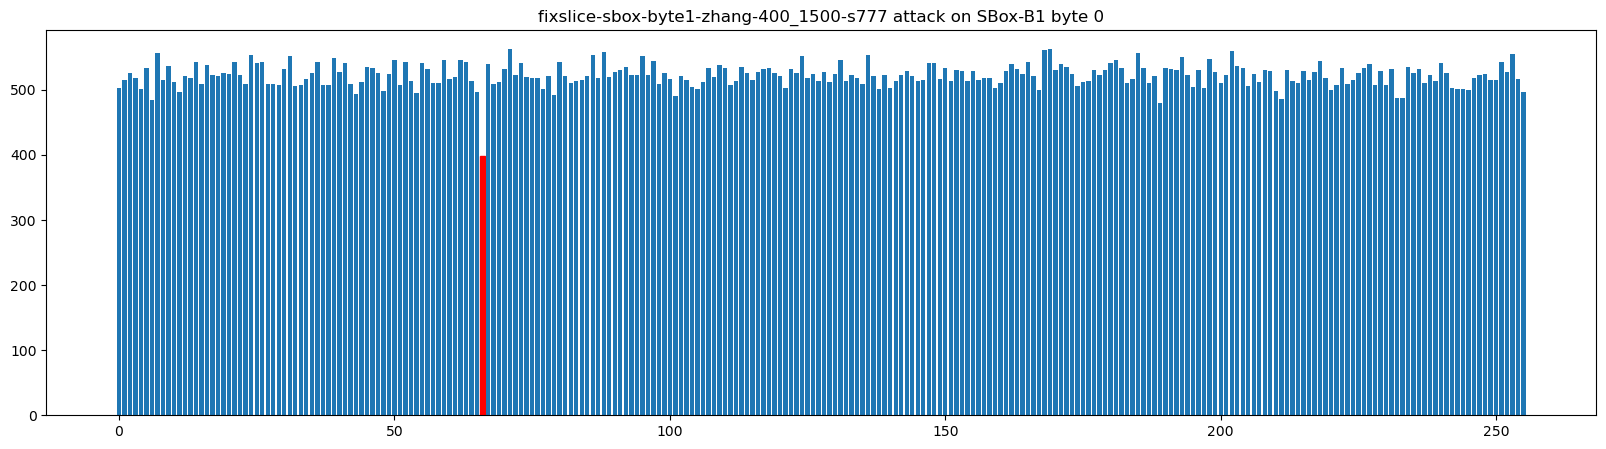

In [ ]:
"""Generate keyscore progression animation"""

print("True key:", key.long().tolist())
true_key =  key.long().tolist()

n_traces = 75

key_scores = model(traces.to(device)[:n_traces])
numpy_key_scores = key_scores.detach().cpu().numpy()

anim_folder = f"misc/keyrank_anim/{model_name}"

os.makedirs(anim_folder, exist_ok=True)

for byte_idx in range(16):
    keybyte = true_key[byte_idx]

    plaintext_bytes = plaintexts[:n_traces, byte_idx]
    plaintext_bytes = plaintext_bytes.long().detach().cpu().numpy().squeeze()

    numpy_keyscores = keyrank_rs.sbox_scores_to_keyscores_parallel(plaintext_bytes, numpy_key_scores)

    x = torch.Tensor(numpy_keyscores).softmax(dim=1).log()


    cumulative = x.cumsum(dim=0) * -1.0

    fig, ax = plt.subplots(1,1)
    fig.set_figheight(5.0)
    fig.set_figwidth(20.0)

    ax.set_title(f"{model_name} attack on SBox-B1 byte {byte_idx}")

    style = "bar"

    if style == "bar":
        bars = ax.bar(np.arange(256), cumulative[-1])
        bars[keybyte].set_color("red")
        def update(frame):
            y = cumulative[frame]
            for height, bar in zip(y, bars):
                bar.set_height(height)
            return bars
    elif style == "scatter":
        line = ax.plot(x.sum(0), '.')

    anim = animation.FuncAnimation(fig=fig, func=update, frames=n_traces, interval=50)
    anim.save(f"{anim_folder}/keybyte{byte_idx}.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.


True key: [186, 104, 67, 93, 4, 12, 6, 196, 201, 218, 86, 51, 25, 36, 9, 3]


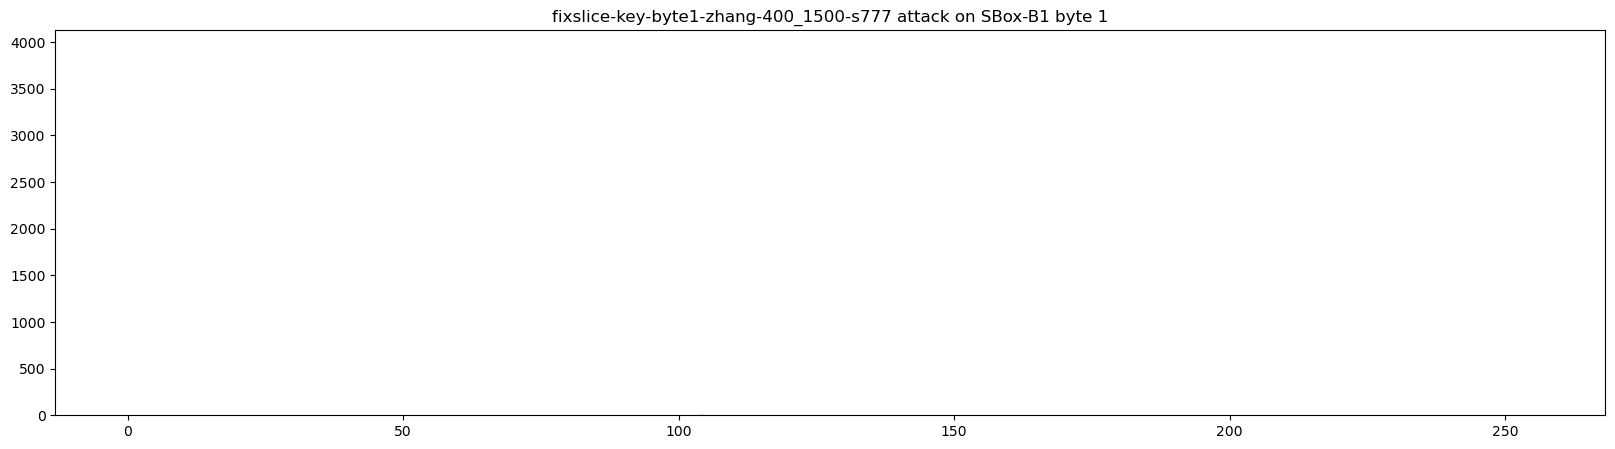

: 

In [ ]:
"""Generate keyscore progression animation for direct key prediction model"""

print("True key:", key.long().tolist())
true_key =  key.long().tolist()

n_traces = 500

key_scores = model(traces.to(device)[:n_traces])
numpy_keyscores = key_scores.detach().cpu().numpy()

anim_folder = f"misc/keyrank_anim/{model_name}"

os.makedirs(anim_folder, exist_ok=True)

byte_idx = TARGET_BYTE_IDX

keybyte = true_key[byte_idx]

x = torch.Tensor(numpy_keyscores).softmax(dim=1).log()


cumulative = x.cumsum(dim=0) * -1.0

fig, ax = plt.subplots(1,1)
fig.set_figheight(5.0)
fig.set_figwidth(20.0)

ax.set_title(f"{model_name} attack on SBox-B1 byte {byte_idx}")

style = "bar"

if style == "bar":
    bars = ax.bar(np.arange(256), cumulative[-1])
    bars[keybyte].set_color("red")
    def update(frame):
        y = cumulative[frame]
        for height, bar in zip(y, bars):
            bar.set_height(height)
        return bars
elif style == "scatter":
    line = ax.plot(x.sum(0), '.')

anim = animation.FuncAnimation(fig=fig, func=update, frames=n_traces, interval=50)
anim.save(f"{anim_folder}/key_keybyte{byte_idx}.gif")